# Step 1.Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2. Load Data

In [5]:
data = pd.read_excel('C:/Users/JOHN/Desktop/Web_Traffic_Project.xlsx')

In [9]:
data.head(10)

,VisitID,Date,UserType,Device,SessionDuration,PagesVisited
0,1,2023-07-01,New,Mobile,120,3
1,2,2023-07-02,Returning,Desktop,300,5
2,3,2023-07-03,New,Tablet,240,4
3,4,2023-07-04,Returning,Mobile,180,3
4,5,2023-07-05,New,Desktop,350,6
5,6,2023-07-06,Returning,Tablet,260,4
6,7,2023-07-07,New,Mobile,190,3
7,8,2023-07-08,Returning,Desktop,400,7
8,9,2023-07-09,New,Tablet,210,4
9,10,2023-07-10,Returning,Mobile,220,5


In [11]:
data.info

<bound method DataFrame.info of    VisitID       Date   UserType   Device  SessionDuration  PagesVisited
0        1 2023-07-01        New   Mobile              120             3
1        2 2023-07-02  Returning  Desktop              300             5
2        3 2023-07-03        New   Tablet              240             4
3        4 2023-07-04  Returning   Mobile              180             3
4        5 2023-07-05        New  Desktop              350             6
5        6 2023-07-06  Returning   Tablet              260             4
6        7 2023-07-07        New   Mobile              190             3
7        8 2023-07-08  Returning  Desktop              400             7
8        9 2023-07-09        New   Tablet              210             4
9       10 2023-07-10  Returning   Mobile              220             5>

# Step 3.Understand the Dataset

In [79]:
# Shape of the dataset
rows, columns = data.shape
print(f"Rows: {rows}")
print(f"Columns: {columns}\n")

# Data types of each column
print("Data Types:\n")
print(data.dtypes, "\n")

# Summary statistics for SessionDuration
print("Summary Statistics:\n")
print("Session Duration:")
print(f"Mean: {data['SessionDuration'].mean():.0f} sec")
print(f"Min: {data['SessionDuration'].min()} sec")
print(f"Max: {data['SessionDuration'].max()} sec\n")

# PagesVisited
print("Pages Visited:")
print(f"Mean: {data['PagesVisited'].mean():.1f} pages")
print(f"Min: {data['PagesVisited'].min()}")
print(f"Max: {data['PagesVisited'].max()}")


Rows: 10
Columns: 6

Data Types:

VisitID                     int64
Date               datetime64[ns]
UserType                   object
Device                     object
SessionDuration             int64
PagesVisited                int64
dtype: object 

Summary Statistics:

Session Duration:
Mean: 247 sec
Min: 120 sec
Max: 400 sec

Pages Visited:
Mean: 4.4 pages
Min: 3
Max: 7


# Step 4: Session Duration by Device (Boxplot)

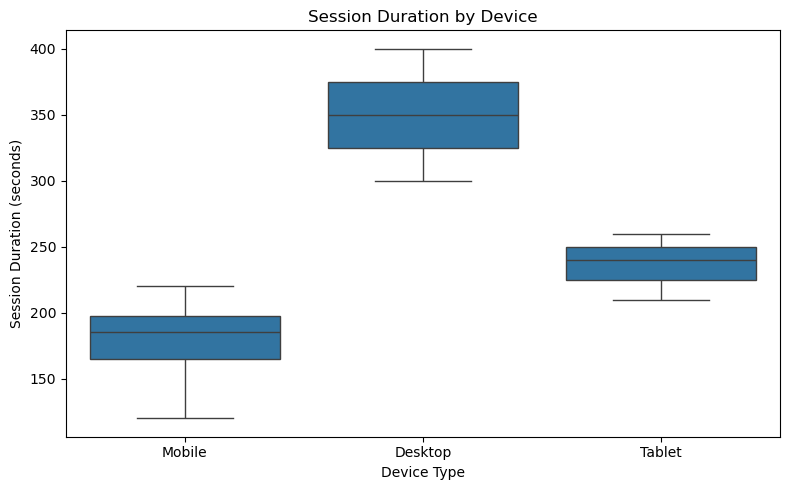

In [70]:
# Datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Plot Boxplot for session duration by device
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Device', y='SessionDuration')
plt.title('Session Duration by Device')
plt.ylabel('Session Duration (seconds)')
plt.xlabel('Device Type')
plt.tight_layout()
plt.show()


# Step 5.Pages Visited by User Type

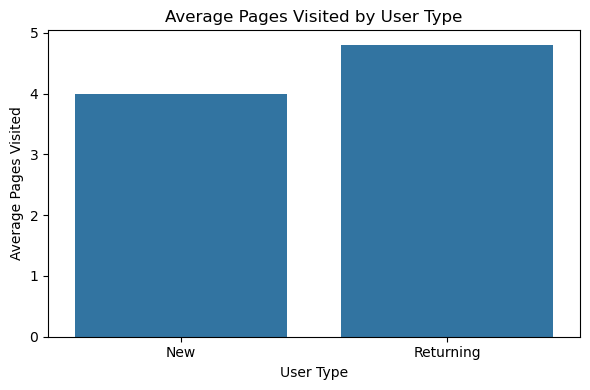

In [31]:
# Date extract to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Group by UserType and calculate average pages visited
user_engagement = data.groupby('UserType')['PagesVisited'].mean().reset_index()

# Plot Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=user_engagement, x='UserType', y='PagesVisited')
plt.title('Average Pages Visited by User Type')
plt.ylabel('Average Pages Visited')
plt.xlabel('User Type')
plt.tight_layout()
plt.show()


In [ ]:
- A higher bar indicates more pages visited on average.

- If Returning users have a higher value, they are likely more engaged.

# Step 6.Trend Over Time-Average Session Duration

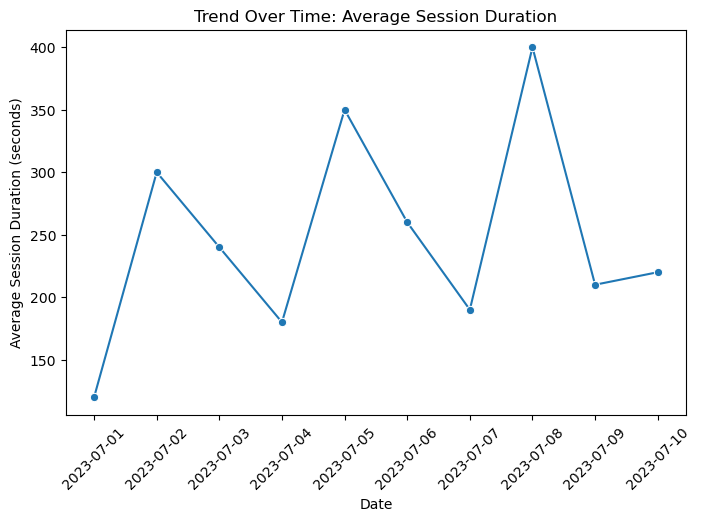

In [40]:
# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Group by date and average session duration
daily_trend = data.groupby('Date')['SessionDuration'].mean().reset_index()

# Line plot of average session duration over time
plt.figure(figsize=(8, 5))
sns.lineplot(data=daily_trend, x='Date', y='SessionDuration', marker='o')
plt.title('Trend Over Time: Average Session Duration')
plt.ylabel('Average Session Duration (seconds)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()


# Step 7.(Optional) Add More Insights

# 1.Pie Chart — Device Usage Distribution

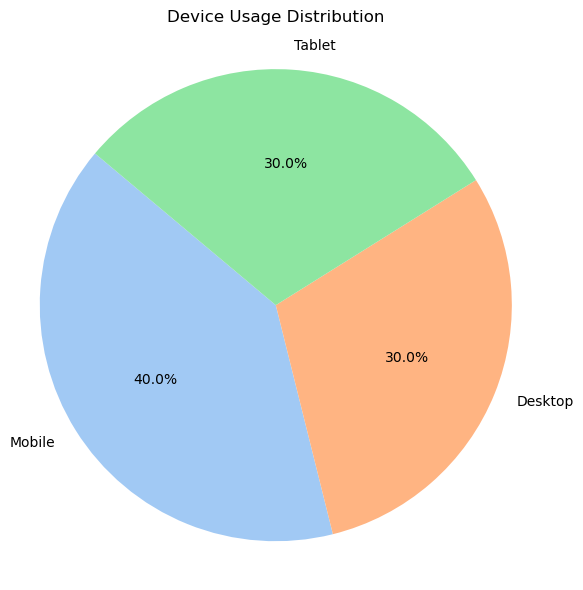

In [43]:
# Count visits by device type
device_counts = data['Device'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Device Usage Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()


# 2.Bar Chart — Average Pages Visited by Device

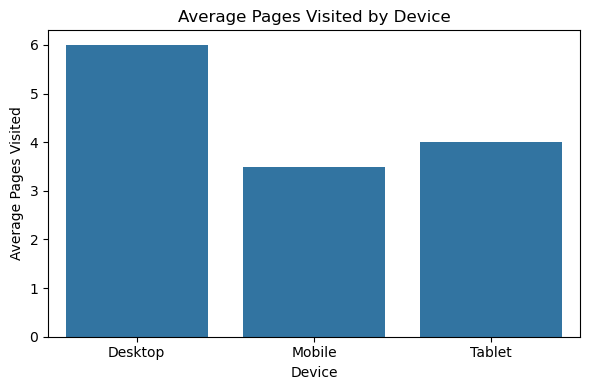

In [52]:
# Group by device and average pages visited
avg_pages_by_device = data.groupby('Device')['PagesVisited'].mean().reset_index()

# Plot Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=avg_pages_by_device, x='Device', y='PagesVisited')
plt.title('Average Pages Visited by Device')
plt.ylabel('Average Pages Visited')
plt.xlabel('Device')
plt.tight_layout()
plt.show()


# 3.Bar Chart — Peak Traffic Days (Based on Number of Visits)

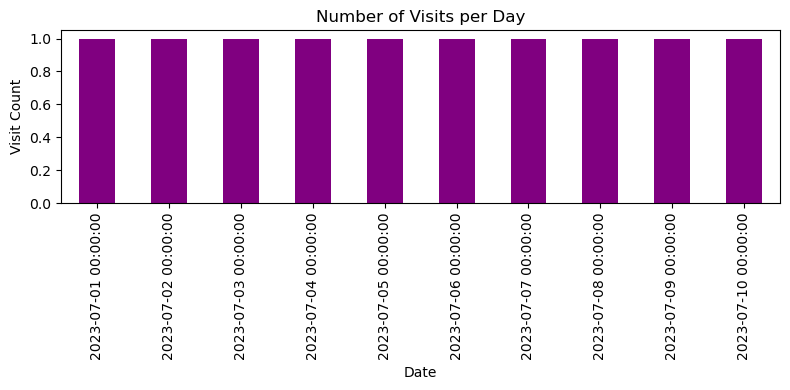

In [59]:
# Count visits per day
daily_visits = data['Date'].value_counts().sort_index()

# Plot Bar chart
plt.figure(figsize=(8, 4))
daily_visits.plot(kind='bar', color='purple')
plt.title('Number of Visits per Day')
plt.ylabel('Visit Count')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


# Step 8.Conclusion

### 1. Which device performs better?

In [73]:
avg_duration_by_device = data.groupby('Device')['SessionDuration'].mean().reset_index().sort_values(by='SessionDuration', ascending=False)

print("Average Session Duration by Device:")
print(avg_duration_by_device)

Average Session Duration by Device:
    Device  SessionDuration
0  Desktop       350.000000
2   Tablet       236.666667
1   Mobile       177.500000


### 2. Are new or returning users more engaged?

In [75]:
avg_pages_by_user_type = data.groupby('UserType')['PagesVisited'].mean().reset_index().sort_values(by='PagesVisited', ascending=False)

print("Average Pages Visited by User Type:")
print(avg_pages_by_user_type)

Average Pages Visited by User Type:
    UserType  PagesVisited
1  Returning           4.8
0        New           4.0


### 3. Any noticeable trends over time?

In [77]:
daily_avg_duration = data.groupby('Date')['SessionDuration'].mean().reset_index()
print(daily_avg_duration)

        Date  SessionDuration
0 2023-07-01            120.0
1 2023-07-02            300.0
2 2023-07-03            240.0
3 2023-07-04            180.0
4 2023-07-05            350.0
5 2023-07-06            260.0
6 2023-07-07            190.0
7 2023-07-08            400.0
8 2023-07-09            210.0
9 2023-07-10            220.0
